In [49]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [50]:
df=df.explode('job_skills')

<Axes: xlabel='job_skills'>

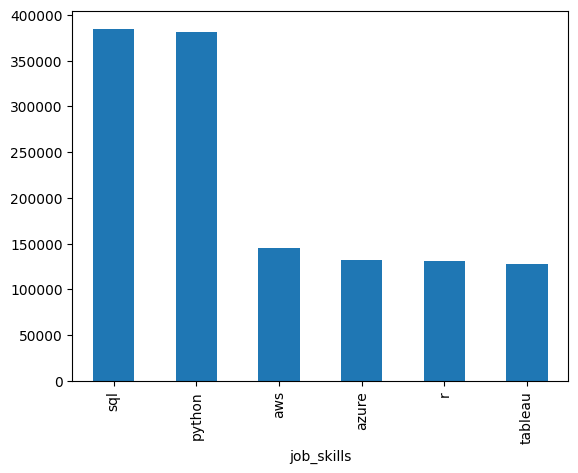

In [51]:
df['job_skills'].value_counts().head(6).plot(kind='bar')

In [52]:
df_temp=df.groupby(['job_title_short','job_skills']).size()

In [53]:
df_temp=df_temp.reset_index(name="skill_count")
df_temp

,job_title_short,job_skills,skill_count
0,Business Analyst,airflow,318
1,Business Analyst,airtable,17
2,Business Analyst,alteryx,1078
3,Business Analyst,angular,87
4,Business Analyst,ansible,120
...,...,...,...
2251,Software Engineer,wrike,4
2252,Software Engineer,wsl,13
2253,Software Engineer,xamarin,35
2254,Software Engineer,yarn,145


In [61]:
df_data_analyst=df_temp[df_temp['job_title_short']=='Data Scientist']

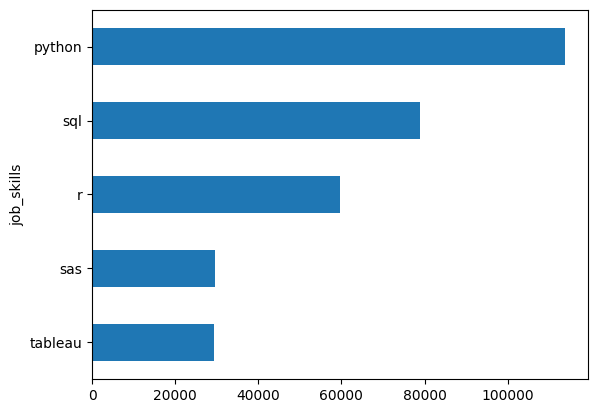

In [66]:
df_data_analyst.sort_values(by="skill_count",ascending=False).head().plot(kind='barh',x='job_skills',y='skill_count')
plt.legend().set_visible(False)
plt.gca().invert_yaxis()